# Canopy Height

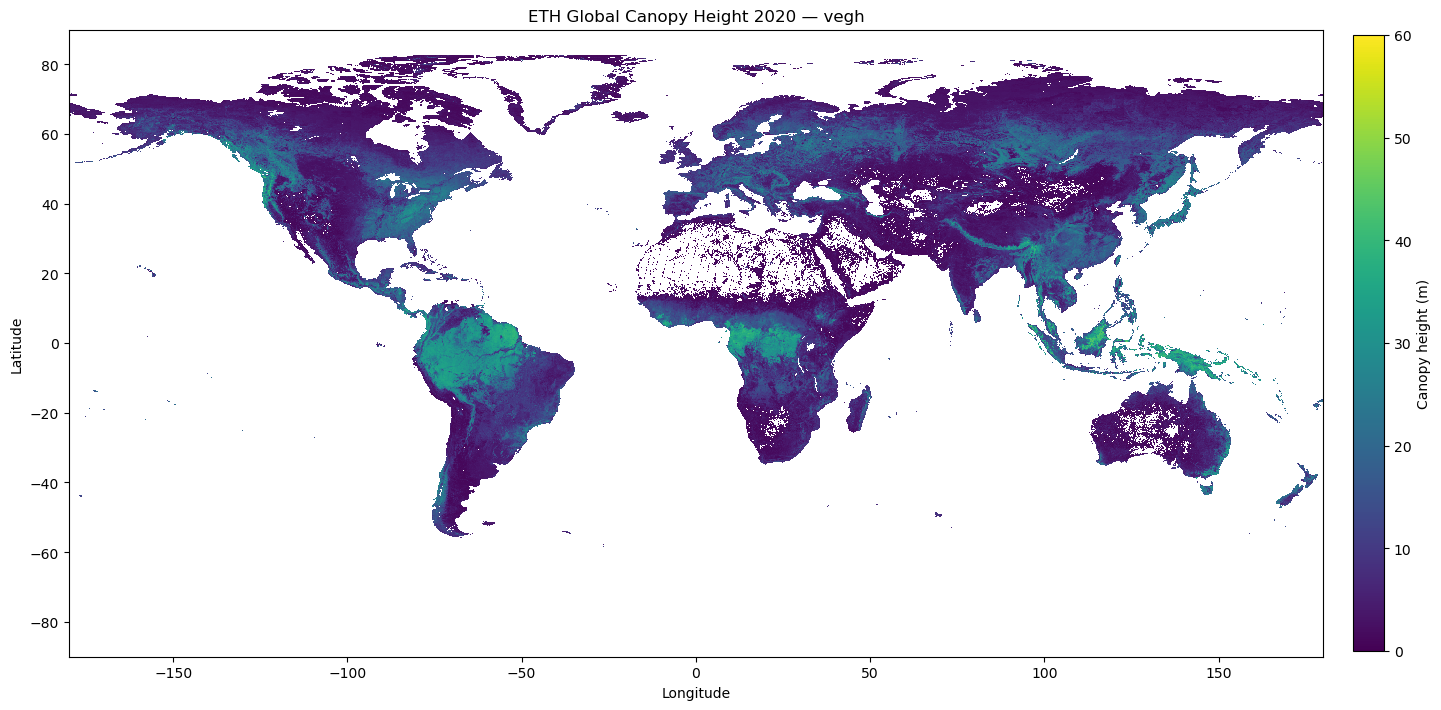

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the NetCDF file
nc_path = "../../scratch/canopy_height/609802/ETH_GlobalCanopyHeight_2020_0p1deg_vegh.nc"
ds = xr.open_dataset(nc_path)

# ds = ds.rename({"Band1": "vegh"})

# Select the first data variable
variable_name = list(ds.data_vars)[0]
canopy_height = ds[variable_name].squeeze()

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

canopy_height.plot(
    ax=ax,
    cmap="viridis",
    vmin=0,
    vmax=60,
    cbar_kwargs={
        "label": "Canopy height (m)",
        "shrink": 0.8,
        "pad": 0.02,
    },
)

ax.set_title(f"ETH Global Canopy Height 2020 — {variable_name}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# LAI

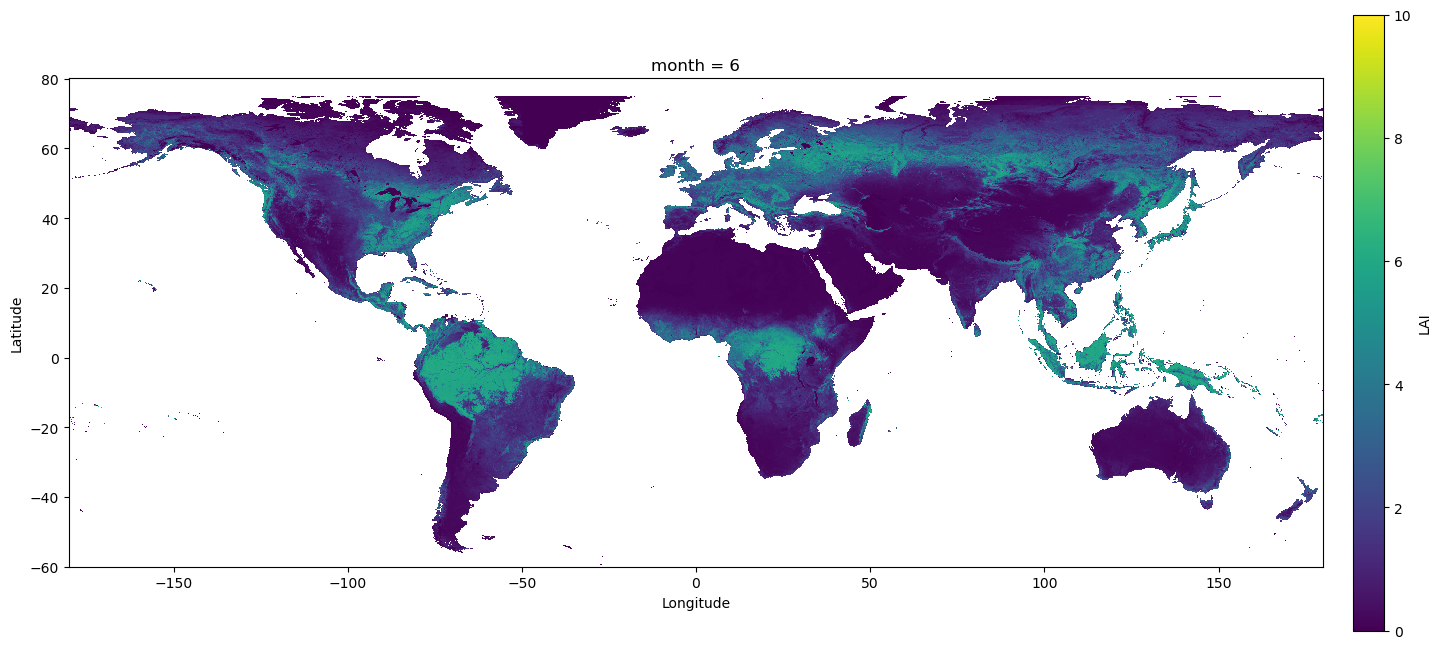

In [14]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the NetCDF file
nc_path = "../../scratch/LAI/VAI_monthly_climatology_2018_2020_global_0p1deg.nc"
ds = xr.open_dataset(nc_path)

# ds = ds.rename({"Band1": "vegh"})

# Select the first data variable
variable_name = list(ds.data_vars)[0]
canopy_height = ds.sel(month=6)[variable_name].squeeze()

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

canopy_height.plot(
    ax=ax,
    cmap="viridis",
    vmin=0,
    vmax=10,
    cbar_kwargs={
        "label": "LAI",
        "shrink": 0.8,
        "pad": 0.02,
    },
)

# ax.set_title(f"ETH Global Canopy Height 2020 — {variable_name}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

CRS: EPSG:4326
Resolution: (0.00892857142858361, 0.0089285714285694)


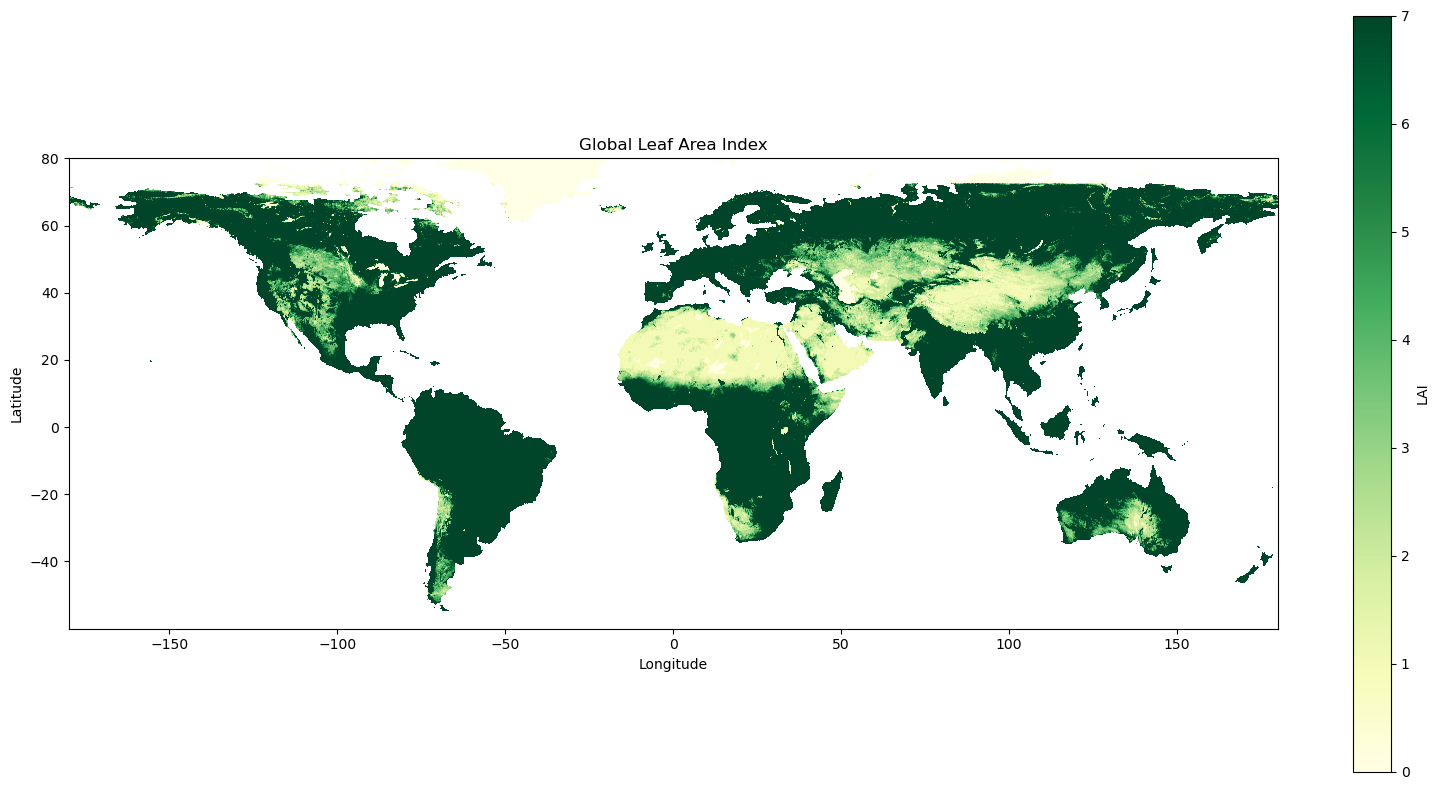

In [9]:
# import rasterio
# import matplotlib.pyplot as plt
# from rasterio.plot import show

# lai_path = "../../scratch/LAI/lai_global_1km_10daily_v2/c_gls_LAI_199903100000_GLOBE_VGT_V2.0.2_cog/c_gls_LAI-LAI_199903100000_GLOBE_VGT_V2.0.2.tiff"

# with rasterio.open(lai_path) as src:
#     lai = src.read(1, masked=True)

#     print(f"CRS: {src.crs}")
#     print(f"Resolution: {src.res}")

#     fig, ax = plt.subplots(figsize=(16, 8))
#     image = show(lai, transform=src.transform, ax=ax, cmap="YlGn", vmin=0, vmax=7)
#     ax.set_title("Global Leaf Area Index")
#     ax.set_xlabel("Longitude")
#     ax.set_ylabel("Latitude")
#     plt.colorbar(image.get_images()[0], ax=ax, label="LAI")
#     plt.tight_layout()
#     plt.show()

# ERA5

In [2]:
from pathlib import Path
import xarray as xr

era5_dir = Path("../../scratch/ERA5_ontario")

era5_datasets = {
    folder.name: xr.open_dataset(nc_file)
    for folder in sorted(era5_dir.iterdir())
    if folder.is_dir()
    for nc_file in folder.glob("*.nc")
}

print(f"Opened {len(era5_datasets)} datasets")
era5_datasets["2018_10"]

Opened 84 datasets


<xarray.Dataset> Size: 123MB
Dimensions:     (valid_time: 744, latitude: 51, longitude: 81)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 2018-10-01 ... 2018-10-31T23:...
  * latitude    (latitude) float64 408B 53.0 52.9 52.8 52.7 ... 48.2 48.1 48.0
  * longitude   (longitude) float64 648B -95.0 -94.9 -94.8 ... -87.2 -87.1 -87.0
    expver      (valid_time) <U4 12kB ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 12MB ...
    t2m         (valid_time, latitude, longitude) float32 12MB ...
    sf          (valid_time, latitude, longitude) float32 12MB ...
    ssrd        (valid_time, latitude, longitude) float32 12MB ...
    strd        (valid_time, latitude, longitude) float32 12MB ...
    u10         (valid_time, latitude, longitude) float32 12MB ...
    v10         (valid_time, latitude, longitude) float32 12MB ...
    sp          (valid_time, latitude, longitude) float32 12MB ...
    tp          (valid_time, latitude, longitude) float32 12MB ...
    w10         (valid_time, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-12T16:46 GRIB to CDM+CF via cfgrib-0.9.1...

Text(0.5, 1.0, 'ERA5 Surface Pressure — October 2018')

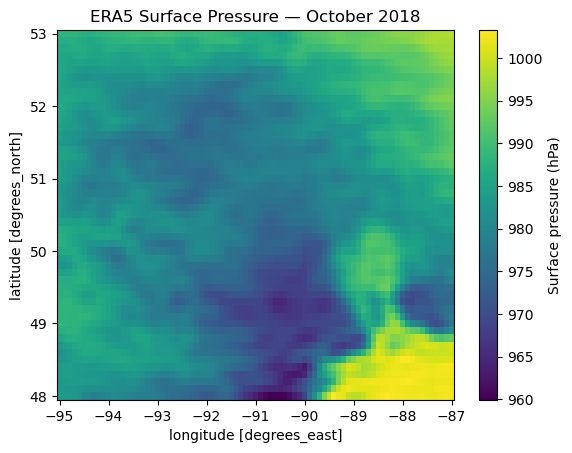

In [8]:
(era5_datasets["2018_10"]["sp"].isel(valid_time=0)/100).plot(cbar_kwargs={"label": "Surface pressure (hPa)"})

# # Plot the first time step, converting Pa to hPa
# (sp.isel(valid_time=0) / 100).plot(
#     figsize=(10, 7),
#     cmap="viridis",
#     cbar_kwargs={"label": "Surface pressure (hPa)"}
# )

plt.title("ERA5 Surface Pressure — October 2018")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.tight_layout()
# plt.show()

# Combining Them

In [11]:
from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import xarray as xr
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling, transform_bounds


# ============================================================
# PATHS
# ============================================================

canopy_path = Path(
    "../../scratch/canopy_height/609802/"
    "ETH_GlobalCanopyHeight_2020_0p1deg_vegh.nc"
)

lai_dir = Path(
    "../../scratch/LAI/lai_global_1km_10daily_v2"
)

era5_dir = Path("../../scratch/ERA5_ontario")
output_dir = Path("../../scratch/FSM2_netcdf_ontario")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def standardise_coordinates(obj):
    """Rename common spatial-coordinate names."""
    rename = {}

    if "lat" in obj.dims or "lat" in obj.coords:
        rename["lat"] = "latitude"
    elif "y" in obj.dims or "y" in obj.coords:
        rename["y"] = "latitude"

    if "lon" in obj.dims or "lon" in obj.coords:
        rename["lon"] = "longitude"
    elif "x" in obj.dims or "x" in obj.coords:
        rename["x"] = "longitude"

    return obj.rename(rename)


def standardise_longitude(obj):
    """Convert 0–360° longitude coordinates to −180–180°."""
    if float(obj.longitude.max()) > 180:
        obj = obj.assign_coords(
            longitude=((obj.longitude + 180) % 360) - 180
        )

    return obj.sortby("longitude")


def coordinate_bounds(values):
    """Return pixel-edge bounds from one-dimensional cell centres."""
    values = np.asarray(values)
    resolution = np.median(np.abs(np.diff(values)))

    return (
        float(values.min() - resolution / 2),
        float(values.max() + resolution / 2),
    )


def read_lai_on_era5_grid(lai_path, shape, transform):
    """Aggregate one LAI raster onto the ERA5 grid."""
    destination = np.full(shape, np.nan, dtype=np.float32)

    with rasterio.open(lai_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=transform,
            dst_crs="EPSG:4326",
            dst_nodata=np.nan,
            resampling=Resampling.average,
        )

        scale = src.scales[0] if src.scales else 1.0
        offset = src.offsets[0] if src.offsets else 0.0

    return destination * scale + offset


# ============================================================
# FIND LAI FILES AND GROUP THEM BY MONTH
# ============================================================

lai_by_month = defaultdict(list)

for lai_path in lai_dir.rglob("c_gls_LAI-LAI_*.tiff"):
    match = re.search(r"LAI-LAI_(\d{4})(\d{2})", lai_path.name)

    if match:
        month_key = f"{match.group(1)}_{match.group(2)}"
        lai_by_month[month_key].append(lai_path)

for month_key in lai_by_month:
    lai_by_month[month_key].sort()

print(f"Found LAI data for {len(lai_by_month)} months")


# ============================================================
# GET COMMON SPATIAL BOUNDS
# ============================================================

era5_files = sorted(era5_dir.glob("*/*.nc"))

if not era5_files:
    raise FileNotFoundError(f"No ERA5 files found under {era5_dir}")

with xr.open_dataset(era5_files[0]) as template:
    template = standardise_coordinates(template)
    template = standardise_longitude(template)
    template = template.sortby("latitude", ascending=False)

    era5_longitude = template.longitude.load()
    era5_latitude = template.latitude.load()

with xr.open_dataset(canopy_path) as canopy_ds:
    canopy_ds = standardise_coordinates(canopy_ds)
    canopy_ds = standardise_longitude(canopy_ds)

    canopy_lon_bounds = coordinate_bounds(canopy_ds.longitude)
    canopy_lat_bounds = coordinate_bounds(canopy_ds.latitude)

first_lai_file = next(iter(lai_by_month.values()))[0]

with rasterio.open(first_lai_file) as src:
    lai_left, lai_bottom, lai_right, lai_top = transform_bounds(
        src.crs,
        "EPSG:4326",
        *src.bounds,
        densify_pts=21,
    )

era5_lon_bounds = coordinate_bounds(era5_longitude)
era5_lat_bounds = coordinate_bounds(era5_latitude)

left = max(era5_lon_bounds[0], canopy_lon_bounds[0], lai_left)
right = min(era5_lon_bounds[1], canopy_lon_bounds[1], lai_right)
bottom = max(era5_lat_bounds[0], canopy_lat_bounds[0], lai_bottom)
top = min(era5_lat_bounds[1], canopy_lat_bounds[1], lai_top)

target_longitude = era5_longitude.where(
    (era5_longitude >= left) & (era5_longitude <= right),
    drop=True,
)

target_latitude = era5_latitude.where(
    (era5_latitude >= bottom) & (era5_latitude <= top),
    drop=True,
)

print(
    f"Common bounds: longitude {left:.3f} to {right:.3f}, "
    f"latitude {bottom:.3f} to {top:.3f}"
)


# ============================================================
# PUT CANOPY HEIGHT ON THE ERA5 GRID
# ============================================================

with xr.open_dataset(canopy_path) as canopy_ds:
    canopy_ds = standardise_coordinates(canopy_ds)
    canopy_ds = standardise_longitude(canopy_ds)
    canopy_ds = canopy_ds.sortby("latitude")

    if "vegh" not in canopy_ds:
        if "Band1" in canopy_ds:
            canopy_ds = canopy_ds.rename({"Band1": "vegh"})
        else:
            raise KeyError("Could not find 'vegh' or 'Band1' in canopy dataset")

    vegh = canopy_ds["vegh"].squeeze(drop=True)

    vegh_on_grid = vegh.interp(
        latitude=target_latitude,
        longitude=target_longitude,
        method="nearest",
    ).load()

vegh_on_grid.name = "vegh"
vegh_on_grid.attrs["long_name"] = "Canopy height"
vegh_on_grid.attrs["units"] = "m"
vegh_on_grid.attrs.pop("grid_mapping", None)


# ============================================================
# DEFINE ERA5 TARGET GRID FOR LAI AGGREGATION
# ============================================================

longitude_values = target_longitude.values
latitude_values = target_latitude.values

longitude_resolution = np.median(np.abs(np.diff(longitude_values)))
latitude_resolution = np.median(np.abs(np.diff(latitude_values)))

target_transform = from_origin(
    longitude_values.min() - longitude_resolution / 2,
    latitude_values.max() + latitude_resolution / 2,
    longitude_resolution,
    latitude_resolution,
)

target_shape = (
    len(latitude_values),
    len(longitude_values),
)


# ============================================================
# CREATE ONE COMBINED NETCDF PER MONTH
# ============================================================

for era5_path in era5_files:
    month_key = era5_path.parent.name
    monthly_lai_files = lai_by_month.get(month_key, [])

    if not monthly_lai_files:
        print(f"Skipping {month_key}: no LAI rasters found")
        continue

    print(
        f"Processing {month_key}: "
        f"{len(monthly_lai_files)} LAI raster(s)"
    )

    # Aggregate each 1 km LAI raster to the ERA5 grid
    lai_layers = [
        read_lai_on_era5_grid(
            lai_path,
            target_shape,
            target_transform,
        )
        for lai_path in monthly_lai_files
    ]

    lai_stack = np.stack(lai_layers)
    valid_count = np.isfinite(lai_stack).sum(axis=0)

    monthly_lai = np.divide(
        np.nansum(lai_stack, axis=0),
        valid_count,
        out=np.full(target_shape, np.nan, dtype=np.float32),
        where=valid_count > 0,
    )

    VAI = xr.DataArray(
        monthly_lai.astype(np.float32),
        dims=("latitude", "longitude"),
        coords={
            "latitude": target_latitude,
            "longitude": target_longitude,
        },
        name="VAI",
        attrs={
            "long_name": "Monthly mean leaf area index",
            "units": "m2 m-2",
            "source": "Copernicus Global Land Service LAI",
        },
    )

    # Open and spatially subset the ERA5 dataset
    with xr.open_dataset(era5_path) as era5_ds:
        era5_ds = standardise_coordinates(era5_ds)
        era5_ds = standardise_longitude(era5_ds)
        era5_ds = era5_ds.sortby("latitude", ascending=False)

        era5_ds = era5_ds.sel(
            latitude=target_latitude.values,
            longitude=target_longitude.values,
        )

        combined_ds = era5_ds.assign(
            vegh=vegh_on_grid,
            VAI=VAI,
        )

        combined_ds.attrs["crs"] = "EPSG:4326"
        combined_ds.attrs["description"] = (
            "Monthly ERA5 data with canopy height and monthly mean LAI"
        )

        # Remove input-file encodings that can conflict with the new dimensions
        for variable in combined_ds.variables:
            combined_ds[variable].encoding = {}

        output_path = output_dir / f"{month_key}.nc"

    #     try:
    #         import netCDF4

    #         encoding = {
    #             variable: {
    #                 "zlib": True,
    #                 "complevel": 4,
    #             }
    #             for variable in combined_ds.data_vars
    #         }

    #         combined_ds.to_netcdf(
    #             output_path,
    #             engine="netcdf4",
    #             encoding=encoding,
    #         )
    #     except ImportError:
    #         combined_ds.to_netcdf(output_path)

    # print(f"Saved: {output_path}")

Found LAI data for 1 months
Common bounds: longitude -95.050 to -86.950, latitude 47.950 to 53.050
Skipping 2018_10: no LAI rasters found
Skipping 2018_11: no LAI rasters found
Skipping 2018_12: no LAI rasters found
Skipping 2019_01: no LAI rasters found
Skipping 2019_02: no LAI rasters found
Skipping 2019_03: no LAI rasters found
Skipping 2019_04: no LAI rasters found
Skipping 2019_05: no LAI rasters found
Skipping 2019_06: no LAI rasters found
Skipping 2019_07: no LAI rasters found
Skipping 2019_08: no LAI rasters found
Skipping 2019_09: no LAI rasters found
Skipping 2019_10: no LAI rasters found
Skipping 2019_11: no LAI rasters found
Skipping 2019_12: no LAI rasters found
Skipping 2020_01: no LAI rasters found
Skipping 2020_02: no LAI rasters found
Skipping 2020_03: no LAI rasters found
Skipping 2020_04: no LAI rasters found
Skipping 2020_05: no LAI rasters found
Skipping 2020_06: no LAI rasters found
Skipping 2020_07: no LAI rasters found
Skipping 2020_08: no LAI rasters found
Skip